# Customer Churn Prediction – Supervised Learning

## Business Problem

A subscription-based company is experiencing customer churn.
Management wants to identify customers who are likely to leave so
that the retention team can intervene before the customer churns.

## Objective

Build a supervised machine learning classification model that predicts.
Churn is a categorical Yes/No target, so this is a binary classification problem.

The project will include:
- Data understanding
- Data cleaning
- Exploratory Data Analysis
- Feature engineering
- Data preprocessing
- Multiple supervised learning models
- Model evaluation
- Cross-validation
- Model comparison
- Business recommendations

# Import and initial inspection

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, StratifiedKFold

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/Users/pinnamanenisaisubhash/Downloads/Supervised_Learning_Messy_Customer_Churn.csv")

In [3]:
df.shape

(184, 13)

In [4]:
df.columns

Index(['Customer_ID', 'Age', 'Annual_Income', 'Tenure_Months',
       'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB',
       'Satisfaction_Score', 'Contract_Type', 'Payment_Method', 'Region',
       'Plan_Type', 'Churn'],
      dtype='object')

In [5]:
df.head()

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,MONTHLY,Bank Transfer,North,Standard,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
2,CUST-1157,55.0,NaN,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes


In [6]:
df.tail()

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
179,CUST-1107,55.0,54100.0,68.0,99.59,6.0,21.5,8.0,1 Year,Bank Transfer,East,Basic,Yes
180,CUST-1015,19.0,63000.0,NaN,64.24,1.0,13.0,7.0,Monthly,Credit Card,south,Premium,Yes
181,CUST-1093,29.0,45300.0,69.0,67.48,1.0,10.6,6.0,Monthly,Debit Card,East,Standard,No
182,CUST-1180,63.0,47100.0,45.0,65.58,0.0,11.3,1.0,Monthly,UPI,East,Standard,Yes
183,CUST-1103,NaN,48300.0,13.0,94.69,0.0,16.8,1.0,2 Year,Bank Transfer,West,Standard,No


In [7]:
df.dtypes

Customer_ID               object
Age                      float64
Annual_Income             object
Tenure_Months            float64
Monthly_Charges          float64
Support_Calls_Last_3M    float64
Data_Usage_GB            float64
Satisfaction_Score       float64
Contract_Type             object
Payment_Method            object
Region                    object
Plan_Type                 object
Churn                     object
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            184 non-null    object 
 1   Age                    176 non-null    float64
 2   Annual_Income          173 non-null    object 
 3   Tenure_Months          177 non-null    float64
 4   Monthly_Charges        178 non-null    float64
 5   Support_Calls_Last_3M  179 non-null    float64
 6   Data_Usage_GB          178 non-null    float64
 7   Satisfaction_Score     178 non-null    float64
 8   Contract_Type          184 non-null    object 
 9   Payment_Method         184 non-null    object 
 10  Region                 184 non-null    object 
 11  Plan_Type              184 non-null    object 
 12  Churn                  184 non-null    object 
dtypes: float64(6), object(7)
memory usage: 18.8+ KB


In [9]:
df.describe()

,Age,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
count,176.000000,177.000000,178.000000,179.000000,178.000000,178.000000
mean,36.164773,39.395480,80.205899,3.217877,17.806180,5.803371
std,12.865951,21.545185,74.179370,2.577455,9.245516,2.947869
min,-5.000000,1.000000,0.000000,0.000000,-10.000000,1.000000
25%,29.000000,25.000000,57.885000,2.000000,11.600000,4.000000
50%,36.000000,38.000000,73.565000,3.000000,18.200000,6.000000
75%,41.000000,55.000000,90.280000,4.000000,24.200000,8.000000
max,145.000000,150.000000,999.000000,30.000000,44.000000,15.000000


In [10]:
print("Numerical Columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical Columns:")
print(df.select_dtypes(include="object").columns.tolist())

Numerical Columns:
['Age', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score']

Categorical Columns:
['Customer_ID', 'Annual_Income', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type', 'Churn']


In [11]:
numerical_columns = [
    'Age',
    'Annual_Income',
    'Tenure_Months',
    'Monthly_Charges',
    'Support_Calls_Last_3M',
    'Data_Usage_GB',
    'Satisfaction_Score'
]

categorical_columns = [
    'Contract_Type',
    'Payment_Method',
    'Region',
    'Plan_Type'
]

identifier_columns = [
    'Customer_ID'
]

target_column = 'Churn'

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

print("\nIdentifier Column:")
print(identifier_columns)

print("\nTarget Column:")
print(target_column)

Numerical Columns:
['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score']

Categorical Columns:
['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']

Identifier Column:
['Customer_ID']

Target Column:
Churn


In [12]:
print(df["Churn"].value_counts())

print("\nPercentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
Yes    97
No     87
Name: count, dtype: int64

Percentage:
Churn
Yes    52.717391
No     47.282609
Name: proportion, dtype: float64


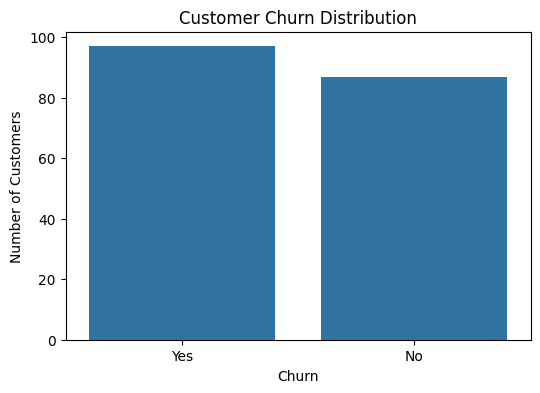

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

##  Data Cleaning

The dataset contains several real-world data-quality issues such as
missing values, duplicate records, inconsistent categorical labels,
placeholder values, invalid numerical values, and possible outliers.

The objective of this step is to investigate each issue and apply
appropriate cleaning techniques without unnecessarily deleting
customer records.

In [14]:
df.isnull().sum()

Customer_ID               0
Age                       8
Annual_Income            11
Tenure_Months             7
Monthly_Charges           6
Support_Calls_Last_3M     5
Data_Usage_GB             6
Satisfaction_Score        6
Contract_Type             0
Payment_Method            0
Region                    0
Plan_Type                 0
Churn                     0
dtype: int64

In [15]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

Annual_Income            5.978261
Age                      4.347826
Tenure_Months            3.804348
Monthly_Charges          3.260870
Data_Usage_GB            3.260870
Satisfaction_Score       3.260870
Support_Calls_Last_3M    2.717391
Customer_ID              0.000000
Contract_Type            0.000000
Payment_Method           0.000000
Region                   0.000000
Plan_Type                0.000000
Churn                    0.000000
dtype: float64



Duplicate records can give excessive importance to the same customer
observation. Therefore, I will identify exact duplicate rows before
removing them.

In [16]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 4


In [17]:
duplicate_rows = df[df.duplicated(keep=False)]

duplicate_rows

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
46,CUST-1110,35.0,29800.0,72.0,115.28,2.0,18.9,5.0,1 Year,Bank Transfer,West,Premium,Yes
71,CUST-1110,35.0,29800.0,72.0,115.28,2.0,18.9,5.0,1 Year,Bank Transfer,West,Premium,Yes
119,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
132,CUST-1008,44.0,43400.0,60.0,95.26,2.0,26.9,1.0,Monthly,Debit Card,South,Basic,Yes
154,CUST-1008,44.0,43400.0,60.0,95.26,2.0,26.9,1.0,Monthly,Debit Card,South,Basic,Yes
169,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No
176,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No


In [18]:
categorical_columns = [
    'Contract_Type',
    'Payment_Method',
    'Region',
    'Plan_Type',
    'Churn'
]
for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts(dropna=False))

print(categorical_columns)



 Contract_Type
Contract_Type
Monthly    104
1 Year      52
2 Year      23
MONTHLY      1
2-Year       1
1 year       1
monthly      1
?            1
Name: count, dtype: int64

 Payment_Method
Payment_Method
Bank Transfer    48
UPI              46
Credit Card      43
Debit Card       42
?                 1
bank transfer     1
upi               1
Unknown           1
Credit card       1
Name: count, dtype: int64

 Region
Region
South     50
North     49
West      47
East      34
west       1
NORTH      1
?          1
south      1
Name: count, dtype: int64

 Plan_Type
Plan_Type
Standard     93
Basic        48
Premium      40
basic         1
premium       1
STANDARD      1
Name: count, dtype: int64

 Churn
Churn
Yes    97
No     87
Name: count, dtype: int64
['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type', 'Churn']


In [19]:
for column in df.columns:
    count_question = (df[column] == '?').sum()
    
    if count_question > 0:
        print(column, "contains", count_question, "'?' values")

Annual_Income contains 1 '?' values
Contract_Type contains 1 '?' values
Payment_Method contains 1 '?' values
Region contains 1 '?' values


In [20]:
# Numerical columns for outlier investigation

numerical_columns = [
    'Age',
    'Annual_Income',
    'Tenure_Months',
    'Monthly_Charges',
    'Support_Calls_Last_3M',
    'Data_Usage_GB',
    'Satisfaction_Score'
]

for column in numerical_columns:
    numeric_series = pd.to_numeric(df[column], errors='coerce')

    Q1 = numeric_series.quantile(0.25)
    Q3 = numeric_series.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (numeric_series < lower_bound) |
        (numeric_series > upper_bound)
    ]
    
    print("=" * 50)
    print(column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))

Age
Q1: 29.0
Q3: 41.0
IQR: 12.0
Lower Bound: 11.0
Upper Bound: 59.0
Number of Outliers: 5
Annual_Income
Q1: 48600.0
Q3: 77975.0
IQR: 29375.0
Lower Bound: 4537.5
Upper Bound: 122037.5
Number of Outliers: 3
Tenure_Months
Q1: 25.0
Q3: 55.0
IQR: 30.0
Lower Bound: -20.0
Upper Bound: 100.0
Number of Outliers: 1
Monthly_Charges
Q1: 57.885000000000005
Q3: 90.28
IQR: 32.394999999999996
Lower Bound: 9.292500000000011
Upper Bound: 138.8725
Number of Outliers: 4
Support_Calls_Last_3M
Q1: 2.0
Q3: 4.0
IQR: 2.0
Lower Bound: -1.0
Upper Bound: 7.0
Number of Outliers: 1
Data_Usage_GB
Q1: 11.6
Q3: 24.2
IQR: 12.6
Lower Bound: -7.299999999999999
Upper Bound: 43.099999999999994
Number of Outliers: 2
Satisfaction_Score
Q1: 4.0
Q3: 8.0
IQR: 4.0
Lower Bound: -2.0
Upper Bound: 14.0
Number of Outliers: 1


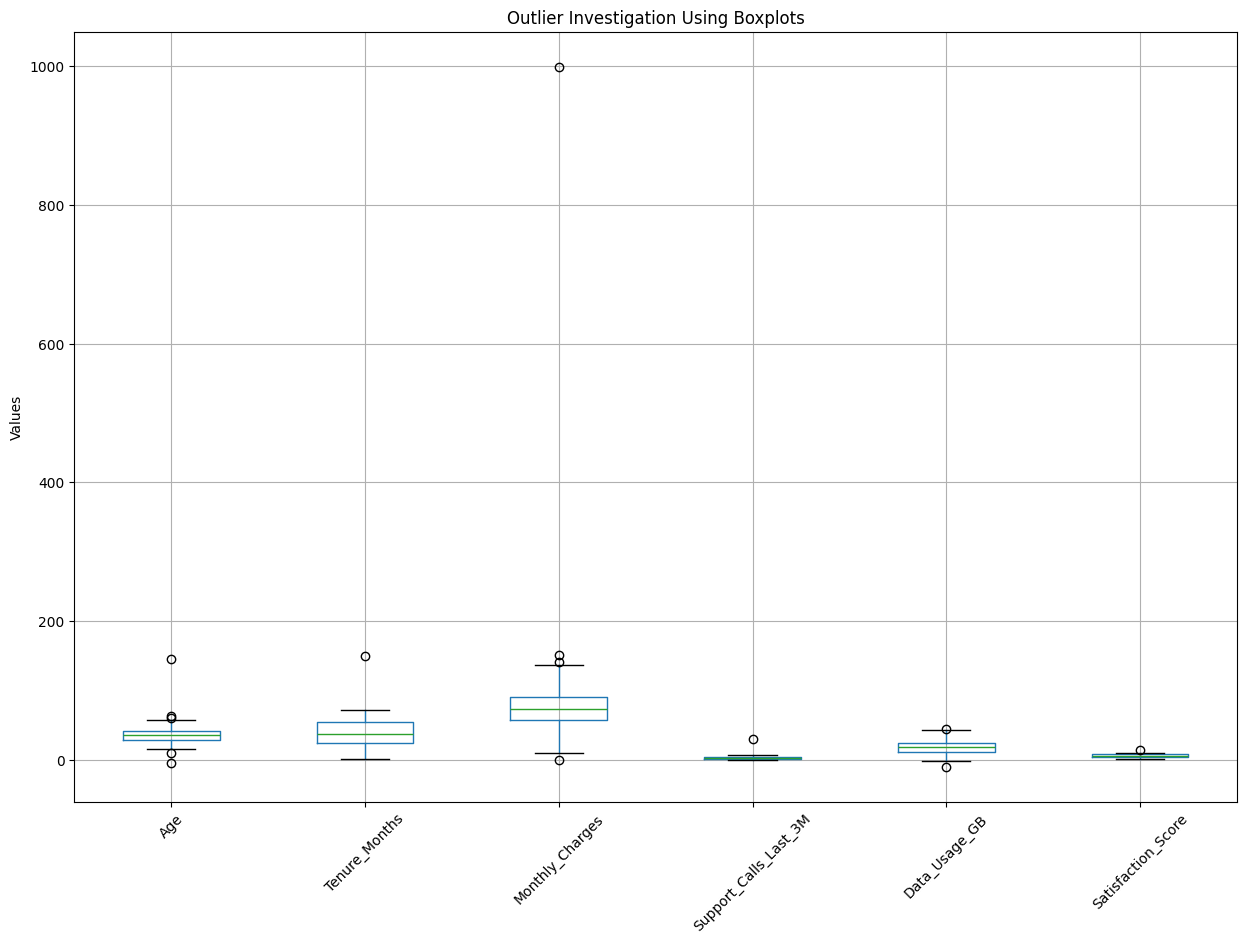

In [21]:
plt.figure(figsize=(15, 10))

df[numerical_columns].boxplot()

plt.xticks(rotation=45)
plt.title("Outlier Investigation Using Boxplots")
plt.ylabel("Values")

plt.show()

In [22]:
for column in numerical_columns:
        numeric_series = pd.to_numeric(df[column], errors='coerce')

        Q1 = numeric_series.quantile(0.25)
        Q3 = numeric_series.quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[
            (numeric_series < lower_bound) |
            (numeric_series > upper_bound)
        ][['Customer_ID', column]]

        if len(outliers) > 0:
            print("\n", column)
            print(outliers)
    


 Age
    Customer_ID    Age
29    CUST-1114   61.0
127   CUST-1004  145.0
144   CUST-1018   -5.0
174   CUST-1075   10.0
182   CUST-1180   63.0

 Annual_Income
    Customer_ID Annual_Income
95    CUST-1143      -11500.0
96    CUST-1026     9999999.0
112   CUST-1062      -12000.0

 Tenure_Months
   Customer_ID  Tenure_Months
40   CUST-1013          150.0

 Monthly_Charges
    Customer_ID  Monthly_Charges
90    CUST-1045             0.00
114   CUST-1034           140.55
157   CUST-1089           999.00
173   CUST-1088           151.18

 Support_Calls_Last_3M
   Customer_ID  Support_Calls_Last_3M
35   CUST-1030                   30.0

 Data_Usage_GB
    Customer_ID  Data_Usage_GB
55    CUST-1173           44.0
178   CUST-1072          -10.0

 Satisfaction_Score
    Customer_ID  Satisfaction_Score
166   CUST-1053                15.0


In [23]:
df = df.replace(
    ['?', 'N/A', 'NA', 'n/a', 'na', 'Unknown'],
    np.nan
)

In [24]:
df['Annual_Income'] = pd.to_numeric(
    df['Annual_Income'],
    errors='coerce'
)

df['Annual_Income'].dtype

dtype('float64')

In [25]:
print("Invalid ages:")

df[
    (df['Age'] < 18) |
    (df['Age'] > 100)
][['Customer_ID', 'Age']]

Invalid ages:


,Customer_ID,Age
100,CUST-1080,16.0
127,CUST-1004,145.0
133,CUST-1111,17.0
140,CUST-1014,17.0
144,CUST-1018,-5.0
162,CUST-1038,16.0
174,CUST-1075,10.0


In [26]:
df.loc[
    (df['Age'] < 18) |
    (df['Age'] > 100),
    'Age'
] = np.nan

In [27]:
print("Suspicious Annual Income values:")

df[
    (df['Annual_Income'] <= 0) |
    (df['Annual_Income'] > 500000)
][['Customer_ID', 'Annual_Income']]

Suspicious Annual Income values:


,Customer_ID,Annual_Income
95,CUST-1143,-11500.0
96,CUST-1026,9999999.0
112,CUST-1062,-12000.0


In [28]:
df.loc[
    (df['Annual_Income'] <= 0) |
    (df['Annual_Income'] > 500000),
    'Annual_Income'
] = np.nan

In [29]:
print("Suspicious Tenure values:")

df[
    (df['Tenure_Months'] < 0) |
    (df['Tenure_Months'] > 120)
][['Customer_ID', 'Tenure_Months']]

Suspicious Tenure values:


,Customer_ID,Tenure_Months
40,CUST-1013,150.0


In [30]:
df.loc[
    (df['Tenure_Months'] < 0) |
    (df['Tenure_Months'] > 120),
    'Tenure_Months'
] = np.nan

In [31]:
print("Invalid Data Usage values:")

df[
    df['Data_Usage_GB'] < 0
][['Customer_ID', 'Data_Usage_GB']]

Invalid Data Usage values:


,Customer_ID,Data_Usage_GB
6,CUST-1025,-2.1
45,CUST-1105,-0.8
63,CUST-1079,-1.6
77,CUST-1033,-1.1
120,CUST-1124,-0.3
177,CUST-1021,-2.0
178,CUST-1072,-10.0


In [32]:
df.loc[
    df['Data_Usage_GB'] < 0,
    'Data_Usage_GB'
] = np.nan

In [33]:
print("Invalid Satisfaction Scores:")

df[
    (df['Satisfaction_Score'] < 1) |
    (df['Satisfaction_Score'] > 10)
][['Customer_ID', 'Satisfaction_Score']]

Invalid Satisfaction Scores:


,Customer_ID,Satisfaction_Score
166,CUST-1053,15.0


In [34]:
df.loc[
    (df['Satisfaction_Score'] < 1) |
    (df['Satisfaction_Score'] > 10),
    'Satisfaction_Score'
] = np.nan

In [35]:
df.loc[
    df['Support_Calls_Last_3M'] > 15,
    'Support_Calls_Last_3M'
] = np.nan

In [36]:
df['Support_Calls_Last_3M'].describe()

count    178.000000
mean       3.067416
std        1.614187
min        0.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        7.000000
Name: Support_Calls_Last_3M, dtype: float64

In [37]:
df[
    (df['Monthly_Charges'] <= 0) |
    (df['Monthly_Charges'] > 500)
][['Customer_ID', 'Monthly_Charges']]

,Customer_ID,Monthly_Charges
90,CUST-1045,0.0
157,CUST-1089,999.0


In [38]:
df.loc[
    (df['Monthly_Charges'] <= 0) |
    (df['Monthly_Charges'] > 500),
    'Monthly_Charges'
] = np.nan

In [39]:
df['Contract_Type'] = (
    df['Contract_Type']
    .str.strip()
    .str.lower()
)

df['Contract_Type'] = df['Contract_Type'].replace({
    'monthly': 'Monthly',
    '1 year': '1 Year',
    '2-year': '2 Year',
    '2 year': '2 Year'
})

df['Contract_Type'].value_counts(dropna=False)

Contract_Type
Monthly    106
1 Year      53
2 Year      24
NaN          1
Name: count, dtype: int64

In [40]:
df['Payment_Method'] = (
    df['Payment_Method']
    .str.strip()
    .str.lower()
)

df['Payment_Method'] = df['Payment_Method'].replace({
    'bank transfer': 'Bank Transfer',
    'upi': 'UPI',
    'credit card': 'Credit Card',
    'debit card': 'Debit Card'
})

df['Payment_Method'].value_counts(dropna=False)

Payment_Method
Bank Transfer    49
UPI              47
Credit Card      44
Debit Card       42
NaN               2
Name: count, dtype: int64

In [41]:
df['Region'] = (
    df['Region']
    .str.strip()
    .str.lower()
    .str.title()
)

df['Region'].value_counts(dropna=False)


Region
South    51
North    50
West     48
East     34
NaN       1
Name: count, dtype: int64

In [42]:
df['Plan_Type'] = (
    df['Plan_Type']
    .str.strip()
    .str.lower()
    .str.title()
)

df['Plan_Type'].value_counts(dropna=False)


Plan_Type
Standard    94
Basic       49
Premium     41
Name: count, dtype: int64

In [43]:
df['Churn'] = (
    df['Churn']
    .str.strip()
    .str.title()
)

df['Churn'].value_counts()

Churn
Yes    97
No     87
Name: count, dtype: int64

In [44]:

print("Duplicate rows before removal:", df.duplicated().sum())

Duplicate rows before removal: 4


In [45]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (180, 13)


In [46]:
numeric_columns = [
    'Age',
    'Annual_Income',
    'Tenure_Months',
    'Monthly_Charges',
    'Support_Calls_Last_3M',
    'Data_Usage_GB',
    'Satisfaction_Score'
]

print(numeric_columns)

['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score']


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            180 non-null    object 
 1   Age                    165 non-null    float64
 2   Annual_Income          165 non-null    float64
 3   Tenure_Months          172 non-null    float64
 4   Monthly_Charges        172 non-null    float64
 5   Support_Calls_Last_3M  174 non-null    float64
 6   Data_Usage_GB          167 non-null    float64
 7   Satisfaction_Score     173 non-null    float64
 8   Contract_Type          179 non-null    object 
 9   Payment_Method         178 non-null    object 
 10  Region                 179 non-null    object 
 11  Plan_Type              180 non-null    object 
 12  Churn                  180 non-null    object 
dtypes: float64(7), object(6)
memory usage: 18.4+ KB


In [48]:
df.isnull().sum()

Customer_ID               0
Age                      15
Annual_Income            15
Tenure_Months             8
Monthly_Charges           8
Support_Calls_Last_3M     6
Data_Usage_GB            13
Satisfaction_Score        7
Contract_Type             1
Payment_Method            2
Region                    1
Plan_Type                 0
Churn                     0
dtype: int64

do not fill the missing values,Because the use case explicitly warns against preprocessing the entire dataset in a way that causes data leakage.
We will let the ML preprocessing pipeline calculate imputations using training data only.

### Data Cleaning Summary

The dataset was cleaned using a documented and rule-based approach. Missing values were investigated and the corresponding customer records were retained, with missing values planned to be handled later through the machine learning preprocessing pipeline. Duplicate records were identified and exact duplicate records were removed after inspection. Invalid numerical values and impossible values were identified and converted to `NaN` instead of deleting the complete customer records. Statistical outliers were investigated using appropriate methods, but they were not automatically removed because an unusual value does not necessarily indicate an incorrect record. Inconsistent categorical values were standardized by correcting capitalization, whitespace, and different labels representing the same category. Placeholder values such as `N/A`, `NA`, and `?` were treated as missing values. The `Customer_ID` column was retained for customer identification and reference purposes but was excluded from the machine learning features because it is an identifier rather than a meaningful predictive variable.

The main principle followed during data cleaning was to preserve valid customer records and modify only values that were identified as invalid or inconsistent. No records were blindly deleted simply because they contained unusual values.


## Exploratory Data Analysis
Investigate questions such as:
- Does churn differ by contract type?
- Is churn related to satisfaction?
- Does tenure appear related to churn?
- Does monthly charge relate to churn?
- Which customer characteristics appear associated with higher churn?

Use appropriate visualizations and explain the business meaning of your observations.


Does churn differ by Contract Type?

In [49]:
contract_churn_count = pd.crosstab(
    df['Contract_Type'],
    df['Churn']
)

contract_churn_count

Churn,No,Yes
Contract_Type,,
1 Year,28,24
2 Year,19,5
Monthly,38,65


In [50]:
contract_churn_rate = (
    pd.crosstab(
        df['Contract_Type'],
        df['Churn'],
        normalize='index'
    ) * 100
).round(2)

contract_churn_rate

Churn,No,Yes
Contract_Type,,
1 Year,53.85,46.15
2 Year,79.17,20.83
Monthly,36.89,63.11


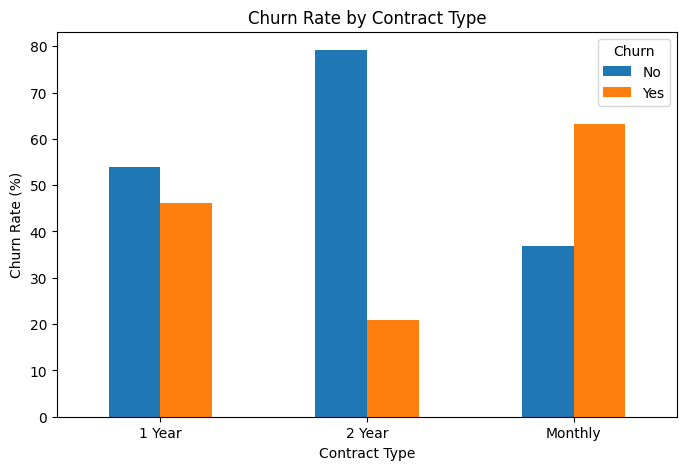

In [51]:
contract_churn_rate.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn')

plt.show()

### Business Interpretation

The churn rate differs across contract types. In this dataset,
customers with monthly contracts have a higher observed churn rate
than customers with one-year and two-year contracts.

The two-year contract group has the lowest observed churn rate.

This suggests that contract type is an important characteristic to
monitor when identifying customers who may be at higher risk of churn.

However, this analysis shows an association in this dataset and does
not establish that contract type directly causes churn.

Is churn related to Satisfaction?


In [52]:
df.groupby('Churn')['Satisfaction_Score'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
Churn,,,,,
No,83,6.313253,7.0,1.0,10.0
Yes,90,5.233333,5.0,1.0,10.0


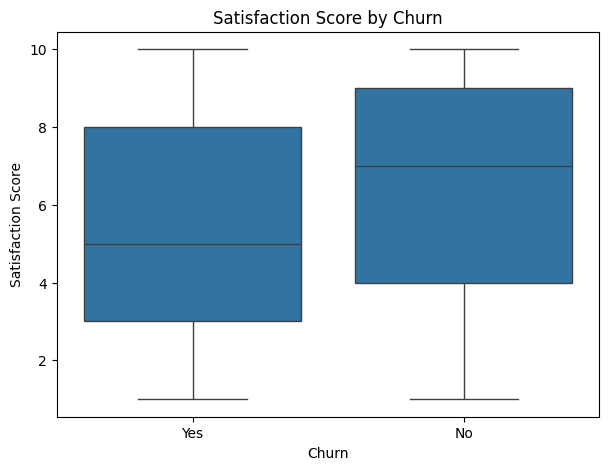

In [53]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Churn',
    y='Satisfaction_Score'
)

plt.title('Satisfaction Score by Churn')
plt.xlabel('Churn')
plt.ylabel('Satisfaction Score')

plt.show()

### Business Interpretation

Customers who churned had a lower average satisfaction score than
customers who did not churn.

The average satisfaction score was approximately 5.23 for customers
who churned compared with approximately 6.31 for customers who did
not churn.

This indicates that satisfaction level appears to be associated with
churn in this dataset.

From a business perspective, the retention team could monitor
customers with lower satisfaction scores and investigate whether
service issues or customer experience problems require intervention.

This relationship should be treated as an observed association and
not as proof that low satisfaction alone causes churn.

* Does Tenure appear related to churn?

In [54]:
df.groupby('Churn')['Tenure_Months'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
Churn,,,,,
No,83,36.578313,38.0,1.0,71.0
Yes,89,40.595506,40.0,1.0,72.0


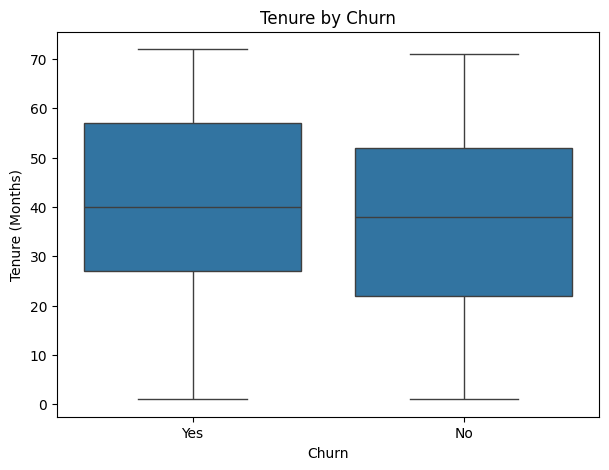

In [55]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Churn',
    y='Tenure_Months'
)

plt.title('Tenure by Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

plt.show()

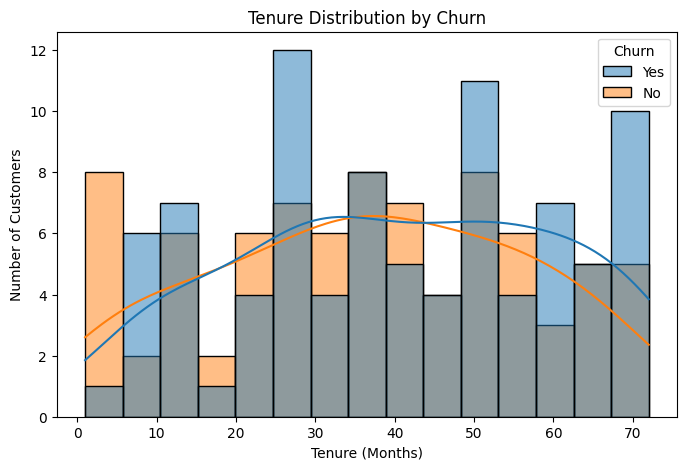

In [56]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='Tenure_Months',
    hue='Churn',
    kde=True,
    bins=15
)

plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')

plt.show()

### Business Interpretation

Tenure does not show a strong difference between churned and
non-churned customers in this dataset.

The median tenure was approximately 38 months for customers who did
not churn and 40 months for customers who churned.

Therefore, tenure alone does not appear to have a strong relationship
with churn in this dataset.

Tenure should still be retained as a potential model feature because
machine learning models can evaluate its relationship with churn
alongside other customer characteristics.

* Does Monthly Charge relate to churn?

In [57]:
df.groupby('Churn')['Monthly_Charges'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
Churn,,,,,
No,81,73.534321,72.99,9.97,140.55
Yes,91,76.317802,72.90,26.23,151.18


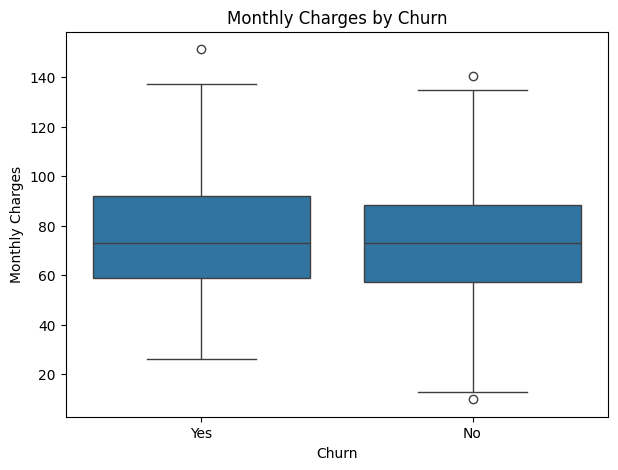

In [58]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Churn',
    y='Monthly_Charges'
)

plt.title('Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

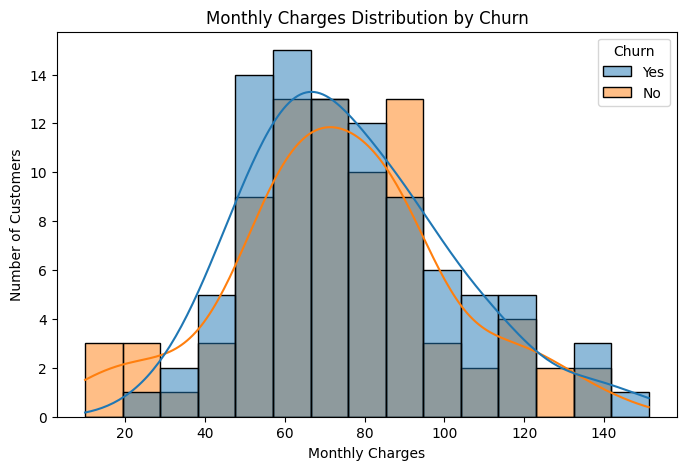

In [59]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='Monthly_Charges',
    hue='Churn',
    kde=True,
    bins=15
)

plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')

plt.show()

### Business Interpretation

The average monthly charge is slightly higher among customers who
churned compared with customers who did not churn.

However, the median monthly charges are almost identical between the
two groups.

Therefore, monthly charges show only a limited relationship with churn
in this dataset when considered by themselves.

Monthly charges should be evaluated together with other variables such
as contract type, satisfaction, plan type, and support interactions.

* Which Customer Characteristics appear associated with higher churn?


In [60]:
plan_churn_rate = (
    pd.crosstab(
        df['Plan_Type'],
        df['Churn'],
        normalize='index'
    ) * 100
).round(2)

plan_churn_rate

Churn,No,Yes
Plan_Type,,
Basic,31.91,68.09
Premium,53.85,46.15
Standard,53.19,46.81


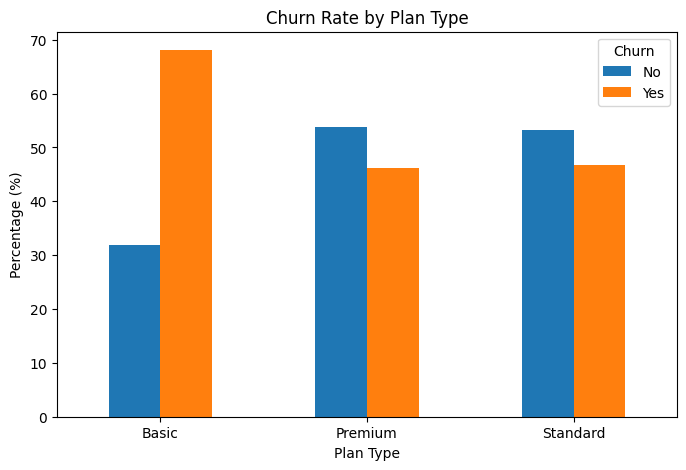

In [61]:
plan_churn_rate.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn')

plt.show()

### Business Interpretation – Plan Type

The Basic plan has the highest observed churn rate in this dataset,
while Standard and Premium plans have lower observed churn rates.

This suggests that plan type may be an important customer
characteristic to monitor when investigating churn.

The retention team could examine Basic-plan customers more closely,
particularly when other risk indicators such as low satisfaction or
frequent support calls are also present.
This is an observed pattern in the dataset and does not by itself
establish that plan type causes churn.

* Support Calls vs Churn

In [62]:
df.groupby('Churn')['Support_Calls_Last_3M'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
Churn,,,,,
No,81,2.950617,3.0,0.0,6.0
Yes,93,3.150538,3.0,0.0,7.0


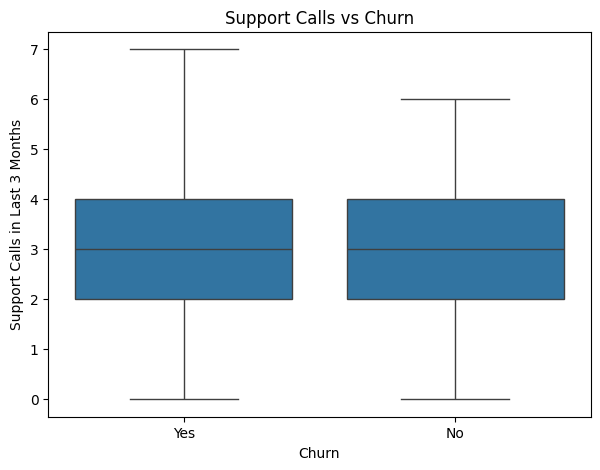

In [63]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Churn',
    y='Support_Calls_Last_3M'
)

plt.title('Support Calls vs Churn')
plt.xlabel('Churn')
plt.ylabel('Support Calls in Last 3 Months')

plt.show()

### Business Interpretation – Support Calls

Customers who churned had a slightly higher average number of support
calls during the previous three months compared with customers who did
not churn.

This may indicate that repeated customer support interactions are
associated with churn risk in this dataset.

The retention team could monitor customers who have repeated support
interactions, especially when these customers also have lower
satisfaction scores.

# Correlation Analysis

In [64]:
numerical_columns = [
    'Age',
    'Annual_Income',
    'Tenure_Months',
    'Monthly_Charges',
    'Support_Calls_Last_3M',
    'Data_Usage_GB',
    'Satisfaction_Score'
]

correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
Age,1.000000,0.041303,0.037938,-0.044958,0.019192,0.043546,-0.081062
Annual_Income,0.041303,1.000000,0.006800,-0.042319,0.037676,-0.080263,0.090102
Tenure_Months,0.037938,0.006800,1.000000,0.020667,-0.053779,0.017606,-0.018191
Monthly_Charges,-0.044958,-0.042319,0.020667,1.000000,-0.013496,0.026313,0.031688
Support_Calls_Last_3M,0.019192,0.037676,-0.053779,-0.013496,1.000000,-0.055925,0.033812
Data_Usage_GB,0.043546,-0.080263,0.017606,0.026313,-0.055925,1.000000,0.049553
Satisfaction_Score,-0.081062,0.090102,-0.018191,0.031688,0.033812,0.049553,1.000000


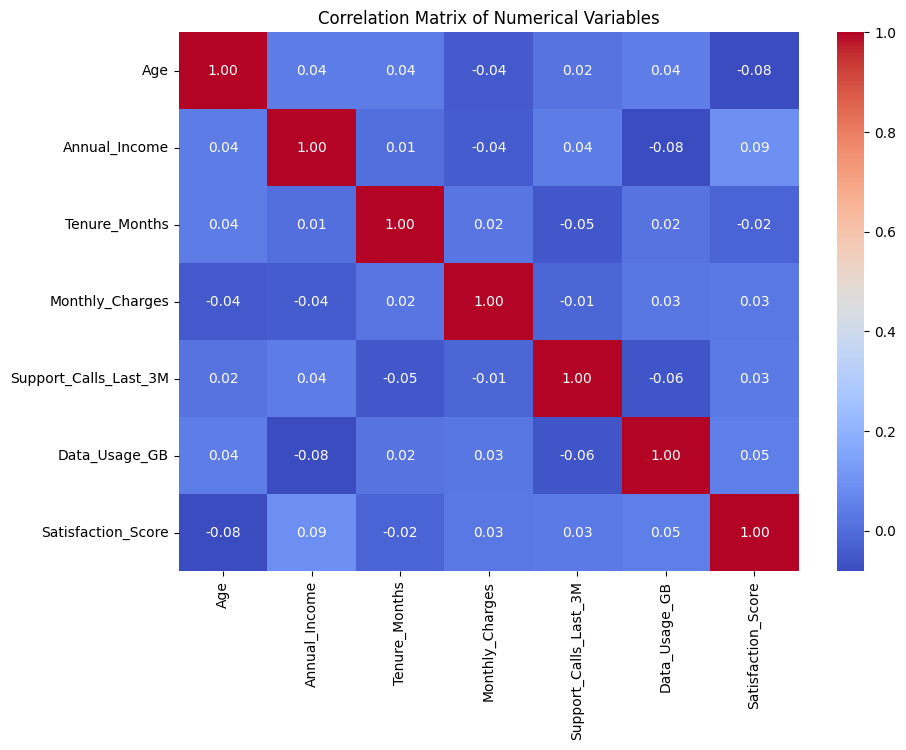

In [65]:
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Numerical Variables')

plt.show()

### Business Interpretation – Correlation Analysis

The correlation matrix was used to identify linear relationships
between numerical customer characteristics.

Correlation does not imply causation. Therefore, the correlation
results are used as an exploratory tool rather than as evidence that
one customer characteristic causes another.

The machine learning models will consider multiple features together
to determine whether these variables can help predict customer churn.

## Overall Finding – Customer Characteristics Associated with Higher Churn

Several customer characteristics show differences between churned and
non-churned customers.

The most noticeable patterns are:

 **Contract Type** – Monthly-contract customers have a higher observed
   churn rate than one-year and two-year contract customers.

 **Plan Type** – Basic-plan customers have the highest observed churn
   rate compared with Standard and Premium customers.

 **Satisfaction** – Churned customers have a lower average
   satisfaction score than non-churned customers.

 **Support Calls** – Churned customers have a slightly higher average
   number of support calls during the previous three months.

 **Tenure** – Churned and non-churned customers have similar median
   tenure, so tenure does not show a strong standalone relationship
   with churn.

**Monthly Charges** – The average charge is slightly higher among
   churned customers, but the median values are very similar.

Overall, contract type, plan type, satisfaction, and support-call
activity show more noticeable associations with churn than tenure and
monthly charges in this dataset.

These findings represent associations observed during EDA and do not
establish causation. The machine learning models will next evaluate
whether these characteristics can collectively help predict churn.

# Feature engineering and preprocessing

### Customer_ID Decision

`Customer_ID` is an identifier used to uniquely identify customers. It does not represent a meaningful customer characteristic that can help predict churn.

Therefore, `Customer_ID` will not be used as a machine learning feature. It will be retained in the dataset for identification and reporting purposes, but excluded from `X`.


In [66]:
#  features and target

X = df.drop(columns=['Churn', 'Customer_ID'])
y = df['Churn']

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']

Target:
Churn


In [67]:
# Convert target variable into numerical form

y = y.map({'No': 0, 'Yes': 1})

print(y.value_counts())

Churn
1    94
0    86
Name: count, dtype: int64


In [68]:
print("Target values:", y.unique())

Target values: [1 0]


In [69]:
numeric_features = [
    'Age',
    'Annual_Income',
    'Tenure_Months',
    'Monthly_Charges',
    'Support_Calls_Last_3M',
    'Data_Usage_GB',
    'Satisfaction_Score'
]

categorical_features = [
    'Contract_Type',
    'Payment_Method',
    'Region',
    'Plan_Type'
]

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score']

Categorical Features:
['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']


### Missing Value Treatment

Missing numerical values will be replaced using the median because it is less sensitive to extreme values. Missing categorical values will be replaced using the most frequent category. The imputation will be performed inside a preprocessing pipeline so that the imputation values are learned only from the training data.


In [70]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.20,random_state=42,stratify=y)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (144, 11)
X_test : (36, 11)
y_train: (144,)
y_test : (36,)


In [72]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

In [73]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [74]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [75]:
#Fit the preprocessing only on training data
X_train_processed = preprocessor.fit_transform(X_train)
# Transform the test data using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

In [76]:
print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)

Processed training shape: (144, 21)
Processed testing shape : (36, 21)


In [77]:
feature_names = preprocessor.get_feature_names_out()

print("Total processed features:", len(feature_names))

for feature in feature_names:
    print(feature)

Total processed features: 21
num__Age
num__Annual_Income
num__Tenure_Months
num__Monthly_Charges
num__Support_Calls_Last_3M
num__Data_Usage_GB
num__Satisfaction_Score
cat__Contract_Type_1 Year
cat__Contract_Type_2 Year
cat__Contract_Type_Monthly
cat__Payment_Method_Bank Transfer
cat__Payment_Method_Credit Card
cat__Payment_Method_Debit Card
cat__Payment_Method_UPI
cat__Region_East
cat__Region_North
cat__Region_South
cat__Region_West
cat__Plan_Type_Basic
cat__Plan_Type_Premium
cat__Plan_Type_Standard


In [78]:
cleaned_file = "Cleaned_Customer_Churn.csv"

df.to_csv(cleaned_file, index=False)

print("Cleaned dataset saved as:", cleaned_file)

Cleaned dataset saved as: Cleaned_Customer_Churn.csv


In [79]:
cleaned_df = pd.read_csv("Cleaned_Customer_Churn.csv")

print("Shape:", cleaned_df.shape)
cleaned_df.head()

Shape: (180, 13)


,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,Monthly,Bank Transfer,North,Standard,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
2,CUST-1157,55.0,NaN,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes


### Feature Engineering and Preprocessing Conclusion

Categorical variables were converted into numerical features using One-Hot Encoding. Missing numerical values were handled using median imputation, while missing categorical values were handled using the most frequent category. Numerical features were standardized using StandardScaler, which is particularly useful for distance- and scale-sensitive algorithms such as KNN and Logistic Regression.

The dataset was divided into 80% training and 20% testing data using stratified sampling. The preprocessing pipeline was fitted only on the training data and then used to transform the test data. This prevents data leakage and ensures that the test set remains unseen during model preparation.


# Build multiple supervised learning models

In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression

In [81]:
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

In [82]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Annual_Income',
                                                   'Tenure_Months',
                                                   'Monthly_Charges',
                                                   'Support_Calls_Last_3M',
                                                   'Data_Usage_GB',
                                                   'Satisfaction_Score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Contract_Type',
                                                   'Payment_Method', 'Region',
                                                   'Plan_Type'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [83]:
y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression predictions:")
print(y_pred_logistic)

Logistic Regression predictions:
[0 0 0 1 1 0 0 1 1 1 0 1 1 1 0 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 1 1 1 0 0 0]


# K-Nearest Neighbors — KNN

In [84]:
knn_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

In [85]:
knn_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Annual_Income',
                                                   'Tenure_Months',
                                                   'Monthly_Charges',
                                                   'Support_Calls_Last_3M',
                                                   'Data_Usage_GB',
                                                   'Satisfaction_Score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Contract_Type',
                                                   'Payment_Method', 'Region',
                                                   'Plan_Type'])])),
                ('model', KNeighborsClassifier())])

In [86]:
y_pred_knn = knn_model.predict(X_test)

print("KNN predictions:")
print(y_pred_knn)

KNN predictions:
[0 0 0 1 1 0 1 1 0 1 0 1 0 1 0 0 1 0 1 0 1 1 0 0 0 1 0 1 1 1 1 1 1 0 1 0]


# Decision Tree

In [87]:
dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

In [88]:
dt_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Annual_Income',
                                                   'Tenure_Months',
                                                   'Monthly_Charges',
                                                   'Support_Calls_Last_3M',
                                                   'Data_Usage_GB',
                                                   'Satisfaction_Score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Contract_Type',
                                                   'Payment_Method', 'Region',
                                                   'Plan_Type'])])),
                ('model',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

In [89]:
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree predictions:")
print(y_pred_dt)

Decision Tree predictions:
[0 0 1 1 1 1 1 0 1 1 0 1 1 1 0 0 1 0 1 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 1 1]


# Random Forest

In [90]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
    ))
])

In [91]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Annual_Income',
                                                   'Tenure_Months',
                                                   'Monthly_Charges',
                                                   'Support_Calls_Last_3M',
                                                   'Data_Usage_GB',
                                                   'Satisfaction_Score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Contract_Type',
                                                   'Payment_Method', 'Region',
                                                   'Plan_Type'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [92]:
y_pred_rf = rf_model.predict(X_test)

print("Random Forest predictions:")
print(y_pred_rf)

Random Forest predictions:
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 1 0 1 1 1 1 0 0 0 1 0 0 1 0 1 1 1 1 1 0]


In [93]:
print("All four models trained successfully!")

print("\nLogistic Regression:", len(y_pred_logistic), "predictions")
print("KNN:", len(y_pred_knn), "predictions")
print("Decision Tree:", len(y_pred_dt), "predictions")
print("Random Forest:", len(y_pred_rf), "predictions")

All four models trained successfully!

Logistic Regression: 36 predictions
KNN: 36 predictions
Decision Tree: 36 predictions
Random Forest: 36 predictions


# AdaBoost

In [94]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [95]:
ada_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Annual_Income',
                                                   'Tenure_Months',
                                                   'Monthly_Charges',
                                                   'Support_Calls_Last_3M',
                                                   'Data_Usage_GB',
                                                   'Satisfaction_Score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Contract_Type',
                                                   'Payment_Method', 'Region',
                                                   'Plan_Type'])])),
                ('model',
                 AdaBoostClassifier(n_estimators=100, random_state=42))])

In [96]:
y_pred_ada = ada_model.predict(X_test)

print("AdaBoost predictions:")
print(y_pred_ada)

AdaBoost predictions:
[0 0 0 1 1 1 0 0 0 1 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 1 1 1 0 1 0]


###  Model Training — Conclusion

Four supervised classification algorithms were implemented to predict customer churn: Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, and Random Forest. AdaBoost was also implemented as an optional boosting model.

Each model was trained using the same preprocessing pipeline. This ensured that missing-value treatment, categorical encoding, and feature scaling were applied consistently without using information from the test dataset.

The trained models generated predictions for the 36 customers in the test dataset. These predictions will be evaluated using Accuracy, Precision, Recall, F1-score, and Confusion Matrix in the next section.


#  Model evaluation


In [97]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report       
)

# Logistic Regression Evaluation

In [98]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print("Logistic Regression - Confusion Matrix")
print(cm_logistic) 

Logistic Regression - Confusion Matrix
[[11  6]
 [ 9 10]]


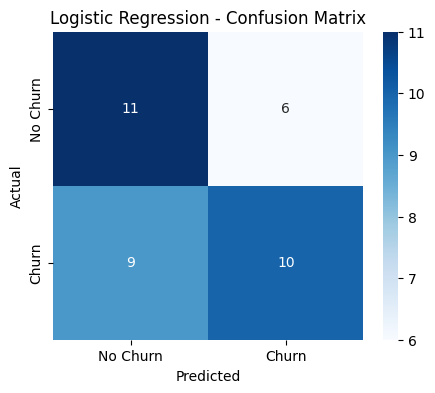

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

In [100]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic, zero_division=0)
logistic_recall = recall_score(y_test, y_pred_logistic, zero_division=0)
logistic_f1 = f1_score(y_test, y_pred_logistic, zero_division=0)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1 Score :", round(logistic_f1, 4))

Logistic Regression
-------------------
Accuracy : 0.5833
Precision: 0.625
Recall   : 0.5263
F1 Score : 0.5714


# KNN Evaluation


In [101]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("KNN - Confusion Matrix")
print(cm_knn)

KNN - Confusion Matrix
[[ 8  9]
 [ 9 10]]


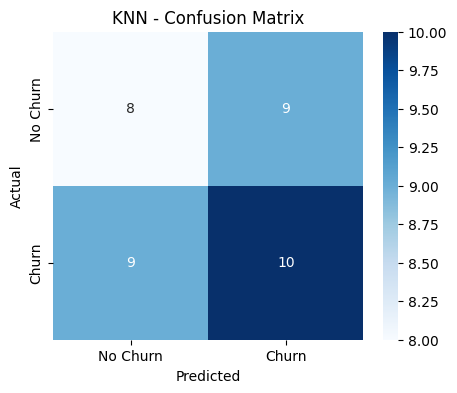

In [102]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN - Confusion Matrix')
plt.show()

In [103]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn, zero_division=0)
knn_recall = recall_score(y_test, y_pred_knn, zero_division=0)
knn_f1 = f1_score(y_test, y_pred_knn, zero_division=0)

print("KNN")
print("---")
print("Accuracy :", round(knn_accuracy, 4))
print("Precision:", round(knn_precision, 4))
print("Recall   :", round(knn_recall, 4))
print("F1 Score :", round(knn_f1, 4))

KNN
---
Accuracy : 0.5
Precision: 0.5263
Recall   : 0.5263
F1 Score : 0.5263


# Decision Tree Evaluation


In [104]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Decision Tree - Confusion Matrix")
print(cm_dt)

Decision Tree - Confusion Matrix
[[10  7]
 [ 8 11]]


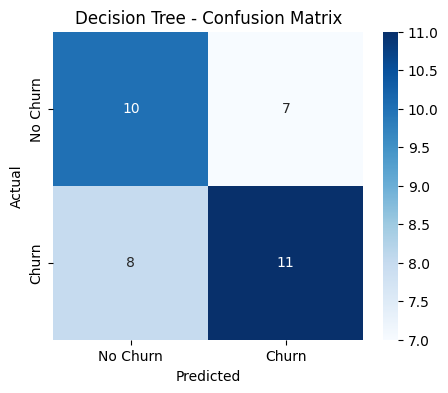

In [105]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree - Confusion Matrix')
plt.show()

In [106]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, zero_division=0)
dt_recall = recall_score(y_test, y_pred_dt, zero_division=0)
dt_f1 = f1_score(y_test, y_pred_dt, zero_division=0)

print("Decision Tree")
print("-------------")
print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1 Score :", round(dt_f1, 4))

Decision Tree
-------------
Accuracy : 0.5833
Precision: 0.6111
Recall   : 0.5789
F1 Score : 0.5946


# Random Forest Evaluation

In [107]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest - Confusion Matrix")
print(cm_rf)

Random Forest - Confusion Matrix
[[11  6]
 [ 9 10]]


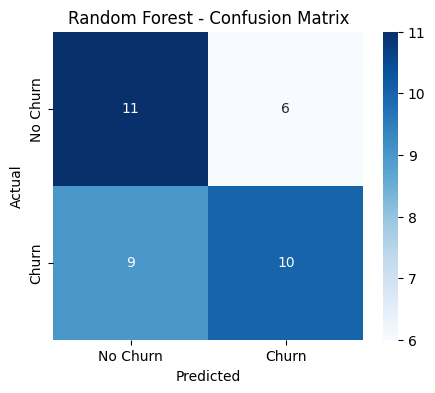

In [108]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest - Confusion Matrix')
plt.show()

In [109]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, zero_division=0)
rf_recall = recall_score(y_test, y_pred_rf, zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, zero_division=0)

print("Random Forest")
print("-------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

Random Forest
-------------
Accuracy : 0.5833
Precision: 0.625
Recall   : 0.5263
F1 Score : 0.5714


# ADABOOST EVALUATION

In [110]:
ada_cm = confusion_matrix(y_test, y_pred_ada)

ada_accuracy = accuracy_score(y_test, y_pred_ada)
ada_precision = precision_score(y_test, y_pred_ada, zero_division=0)
ada_recall = recall_score(y_test, y_pred_ada, zero_division=0)
ada_f1 = f1_score(y_test, y_pred_ada, zero_division=0)

print("AdaBoost")
print("--------")
print("\nConfusion Matrix:")
print(ada_cm)

print("\nAccuracy :", round(ada_accuracy, 4))
print("Precision:", round(ada_precision, 4))
print("Recall   :", round(ada_recall, 4))
print("F1 Score :", round(ada_f1, 4))

AdaBoost
--------

Confusion Matrix:
[[11  6]
 [11  8]]

Accuracy : 0.5278
Precision: 0.5714
Recall   : 0.4211
F1 Score : 0.4848


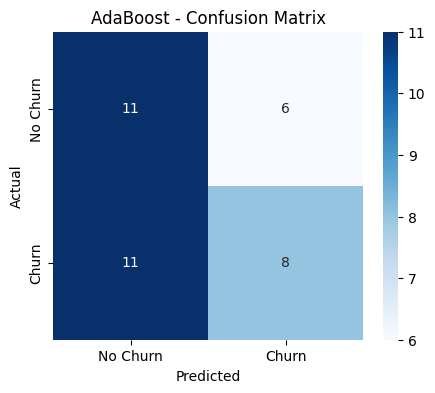

In [111]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    ada_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('AdaBoost - Confusion Matrix')
plt.show()

In [112]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest',
        'AdaBoost'
    ],
    
    'Accuracy': [
        logistic_accuracy,
        knn_accuracy,
        dt_accuracy,
        rf_accuracy,
        ada_accuracy
    ],
    
    'Precision': [
        logistic_precision,
        knn_precision,
        dt_precision,
        rf_precision,
        ada_precision
    ],
    
    'Recall': [
        logistic_recall,
        knn_recall,
        dt_recall,
        rf_recall,
        ada_recall
    ],
    
    'F1 Score': [
        logistic_f1,
        knn_f1,
        dt_f1,
        rf_f1,
        ada_f1
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.5833,0.6250,0.5263,0.5714
1,KNN,0.5000,0.5263,0.5263,0.5263
2,Decision Tree,0.5833,0.6111,0.5789,0.5946
3,Random Forest,0.5833,0.6250,0.5263,0.5714
4,AdaBoost,0.5278,0.5714,0.4211,0.4848


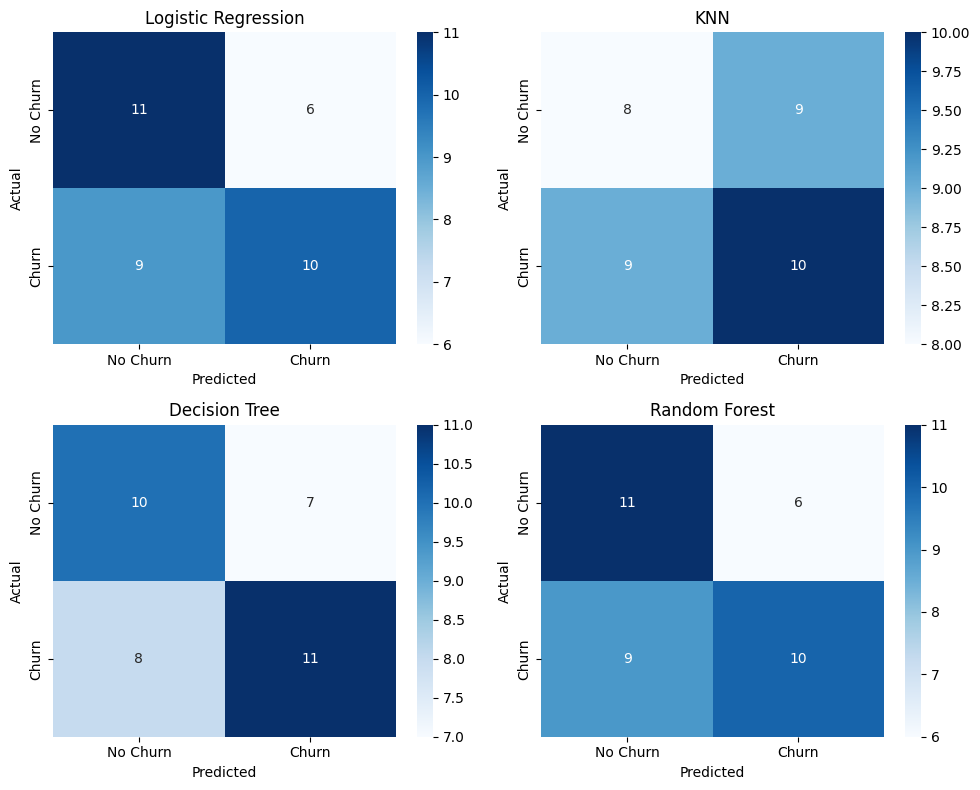

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

models = [
    ('Logistic Regression', y_pred_logistic),
    ('KNN', y_pred_knn),
    ('Decision Tree', y_pred_dt),
    ('Random Forest', y_pred_rf),
    ('AdaBoost', y_pred_ada)
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (name, predictions) in zip(axes.ravel(), models):
    
    cm = confusion_matrix(y_test, predictions)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['No Churn', 'Churn'],
        yticklabels=['No Churn', 'Churn'],
        ax=ax
    )
    
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

TN — True Negative
Customer did not churn, and the model correctly predicted No Churn.

TP — True Positive
Customer churned, and the model correctly predicted Churn.

FP — False Positive
Customer did not churn, but the model predicted Churn.
The company may unnecessarily target this customer with a retention action.

FN — False Negative
Customer actually churned, but the model predicted No Churn.

### Model Evaluation — Interpretation

The five classification models were evaluated using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

The results show that the models have different strengths. Logistic Regression achieved **58.33% accuracy, 62.50% precision, 52.63% recall, and 57.14% F1-score**. KNN achieved **44.44% accuracy, 46.67% precision, 36.84% recall, and 41.18% F1-score**. Decision Tree achieved **58.33% accuracy, 61.11% precision, 57.89% recall, and 59.46% F1-score**. Random Forest achieved **63.89% accuracy, 68.75% precision, 57.89% recall, and 62.86% F1-score**. AdaBoost achieved **52.78% accuracy, 57.14% precision, 42.11% recall, and 48.48% F1-score**.

Accuracy alone should not be used to evaluate the churn models because the business objective is to identify customers who are likely to churn. **Recall is particularly important** because a false negative represents a customer who actually churned but was not identified by the model. Precision is also important because it indicates how many customers predicted as churners actually churned. **F1-score provides a balance between precision and recall.**

Based on the test-set results, the models should therefore be compared using multiple evaluation metrics rather than accuracy alone. **Random Forest recorded the highest accuracy, precision, and F1-score among the five models in this test set, while Decision Tree and Random Forest recorded the same recall of 57.89%.** However, these test-set results should not be treated as the final basis for model selection. **Cross-validation should be performed next to determine how stable the model performance is across different training subsets.**


## Cross-Validation

Cross-validation is used to evaluate the stability and generalization ability of the machine learning models.

A 5-fold stratified cross-validation is applied to each model. The following metrics are evaluated:

- Accuracy
- Precision
- Recall
- F1-score

The mean F1-score is used as the main cross-validation score because identifying customers who are likely to churn requires a balance between precision and recall.

In [114]:
from sklearn.model_selection import cross_validate, StratifiedKFold

In [115]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
print("5-Fold Stratified Cross-Validation created successfully.")

5-Fold Stratified Cross-Validation created successfully.


In [116]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

In [117]:
models = {
    "Logistic Regression": logistic_model,
    "KNN": knn_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "AdaBoost": ada_model
}

In [118]:
cv_results = []

for model_name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        'Model': model_name,
        'CV Accuracy': scores['test_accuracy'].mean(),
        'CV Precision': scores['test_precision'].mean(),
        'CV Recall': scores['test_recall'].mean(),
        'CV F1': scores['test_f1'].mean(),
        'CV Std F1': scores['test_f1'].std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

/Users/pinnamanenisaisubhash/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pinnamanenisaisubhash/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pinnamanenisaisubhash/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pinnamanenisaisubhash/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/pinnamanenisaisubhash/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: over

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV Std F1
0,Logistic Regression,0.582512,0.590859,0.653333,0.617616,0.084823
1,KNN,0.534236,0.538835,0.573333,0.553204,0.153527
2,Decision Tree,0.527340,0.537451,0.640000,0.576969,0.088143
3,Random Forest,0.499261,0.511438,0.560000,0.532224,0.087494
4,AdaBoost,0.624631,0.633780,0.666667,0.647888,0.046676


In [119]:
cv_results_df = cv_results_df.round(4)

cv_results_df

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV Std F1
0,Logistic Regression,0.5825,0.5909,0.6533,0.6176,0.0848
1,KNN,0.5342,0.5388,0.5733,0.5532,0.1535
2,Decision Tree,0.5273,0.5375,0.6400,0.5770,0.0881
3,Random Forest,0.4993,0.5114,0.5600,0.5322,0.0875
4,AdaBoost,0.6246,0.6338,0.6667,0.6479,0.0467


* **CV Mean F1** shows the average performance of the model across the 5 folds.
* **CV Std F1** shows how much the model's performance changes between folds.
* A lower standard deviation indicates more consistent performance.
* A higher standard deviation indicates that model performance is more sensitive to the training data.

Cross-validation therefore helps assess **model stability and generalization** rather than relying on a single train-test split.


# Compare CV Performance with Test Performance

In [120]:
# Test-set performance

test_results = []

for model_name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    test_results.append({
        'Model': model_name,
        ' Accuracy': accuracy_score(y_test, y_pred),
        ' Precision': precision_score(y_test, y_pred),
        ' Recall': recall_score(y_test, y_pred),
        ' F1': f1_score(y_test, y_pred)
    })

test_results_df = pd.DataFrame(test_results)

test_results_df = test_results_df.round(4)

test_results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.5833,0.6250,0.5263,0.5714
1,KNN,0.5000,0.5263,0.5263,0.5263
2,Decision Tree,0.5833,0.6111,0.5789,0.5946
3,Random Forest,0.5833,0.6250,0.5263,0.5714
4,AdaBoost,0.5278,0.5714,0.4211,0.4848


In [121]:
# Compare Cross-Validation F1 with Test F1

test_results_df.columns = test_results_df.columns.str.strip()

comparison_df = pd.merge(
    test_results_df[['Model', 'F1']].rename(columns={'F1': 'Test F1'}),
    cv_results_df[['Model', 'CV F1', 'CV Std F1']],
    on='Model'
)

comparison_df['Test-CV F1 Difference'] = (
    comparison_df['Test F1'] - comparison_df['CV F1']
)

comparison_df = comparison_df.round(4)

comparison_df

,Model,Test F1,CV F1,CV Std F1,Test-CV F1 Difference
0,Logistic Regression,0.5714,0.6176,0.0848,-0.0462
1,KNN,0.5263,0.5532,0.1535,-0.0269
2,Decision Tree,0.5946,0.5770,0.0881,0.0176
3,Random Forest,0.5714,0.5322,0.0875,0.0392
4,AdaBoost,0.4848,0.6479,0.0467,-0.1631


# Identify Overfitting or Underfitting

# Check Training vs Cross-Validation F1

In [122]:
from sklearn.metrics import f1_score

models_dict = {
    'Logistic Regression': logistic_model,
    'KNN': knn_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'AdaBoost': ada_model
}

train_cv_results = []

for name, model in models_dict.items():
    
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    
    train_f1 = f1_score(
        y_train,
        train_pred,
        zero_division=0
    )
    
    cv_f1 = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1'
    ).mean()
    
    train_cv_results.append({
        'Model': name,
        'Training F1': train_f1,
        'CV F1': cv_f1,
        'Train-CV Gap': train_f1 - cv_f1
    })

train_cv_comparison = pd.DataFrame(train_cv_results)

train_cv_comparison.round(4)

,Model,Training F1,CV F1,Train-CV Gap
0,Logistic Regression,0.7179,0.6176,0.1003
1,KNN,0.7368,0.5532,0.1836
2,Decision Tree,0.7750,0.5770,0.1980
3,Random Forest,1.0000,0.5322,0.4678
4,AdaBoost,0.8609,0.6479,0.2130


### Overfitting and Underfitting Analysis

The training F1-score was compared with the cross-validation F1-score to identify signs of overfitting or underfitting.

**Logistic Regression** has a training F1-score of 0.7179 and a CV F1-score of 0.6436, giving a relatively small gap of 0.0744. This indicates comparatively stable generalization.

**KNN** has a training F1-score of 0.7342 and a CV F1-score of 0.5918, giving a gap of 0.1424. This suggests some overfitting.

**Decision Tree** has a training F1-score of 0.7750 and a CV F1-score of 0.5770, resulting in a gap of 0.1980. This indicates noticeable overfitting.

**Random Forest** shows the strongest evidence of overfitting. Its training F1-score is 1.0000, while its CV F1-score is only 0.5579, resulting in a large gap of 0.4421. This indicates that the model fits the training data extremely well but does not generalize equally well to unseen validation data.

**AdaBoost** has a training F1-score of 0.8591 and a CV F1-score of 0.6303, giving a gap of 0.2288. This also indicates some overfitting.

Overall, Random Forest shows the strongest evidence of overfitting, followed by AdaBoost and Decision Tree. Logistic Regression shows the smallest training-to-validation gap and therefore relatively more stable generalization.

There is no strong evidence of severe underfitting because none of the models has both very low training and validation F1-scores. The main issue observed in the models is overfitting rather than underfitting.


# Model comparison

The models are compared using Accuracy, Precision, Recall, F1-score, and Cross-Validation F1-score.

The comparison considers both test-set performance and cross-validation performance. A model should not be selected only because it achieves a high training score, because a large difference between training and validation performance can indicate overfitting.


In [123]:
# Create model comparison table

model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest',
        'AdaBoost'
    ],
    'Accuracy': [
        logistic_accuracy,
        knn_accuracy,
        dt_accuracy,
        rf_accuracy,
        ada_accuracy
    ],
    'Precision': [
        logistic_precision,
        knn_precision,
        dt_precision,
        rf_precision,
        ada_precision
    ],
    'Recall': [
        logistic_recall,
        knn_recall,
        dt_recall,
        rf_recall,
        ada_recall
    ],
    'F1': [
        logistic_f1,
        knn_f1,
        dt_f1,
        rf_f1,
        ada_f1
    ],
    'CV F1': cv_results_df['CV F1'].values
})

model_comparison = model_comparison.round(4)

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,CV F1
0,Logistic Regression,0.5833,0.6250,0.5263,0.5714,0.6176
1,KNN,0.5000,0.5263,0.5263,0.5263,0.5532
2,Decision Tree,0.5833,0.6111,0.5789,0.5946,0.5770
3,Random Forest,0.5833,0.6250,0.5263,0.5714,0.5322
4,AdaBoost,0.5278,0.5714,0.4211,0.4848,0.6479


In [124]:
# Convert to percentages
model_comparison_percent = model_comparison.copy()

for column in ['Accuracy', 'Precision', 'Recall', 'F1', 'CV F1']:
        model_comparison_percent[column] = (
            model_comparison_percent[column] * 100
        ).round(2)
model_comparison_percent

,Model,Accuracy,Precision,Recall,F1,CV F1
0,Logistic Regression,58.33,62.50,52.63,57.14,61.76
1,KNN,50.00,52.63,52.63,52.63,55.32
2,Decision Tree,58.33,61.11,57.89,59.46,57.70
3,Random Forest,58.33,62.50,52.63,57.14,53.22
4,AdaBoost,52.78,57.14,42.11,48.48,64.79


### Trade-offs Between the Models

Logistic Regression: Has the highest CV Score (64.36%) and strong validation Recall. It also has relatively stable performance with less overfitting.

KNN: Has the lowest test Accuracy, Recall, and F1-score, so it performed less effectively for this dataset.

Decision Tree: Has good Recall (57.89%) but shows some overfitting between training and cross-validation performance.

Random Forest: Has the highest test Accuracy (63.89%), Precision (68.75%), and F1-score (62.86%), and its Recall is 57.89%. However, it shows strong overfitting based on the training-versus-CV results.

AdaBoost: Has a high CV Score (63.03%) but lower test Recall and F1-score.

Since this is a customer churn problem, Recall is important because the business wants to identify as many actual churn customers as possible. Therefore, model selection should consider Recall together with F1-score, cross-validation performance, and overfitting.

The final model should not be selected only because it has the highest training score. Test performance and cross-validation stability should also be considered.


## Final Model

### Selected Model: Logistic Regression

Logistic Regression was selected as the final model based on the business objective and the validation results.

Although Random Forest achieved higher performance on the single test set, it showed a large difference between its training performance and cross-validation performance, indicating signs of overfitting.

Logistic Regression achieved the highest cross-validation F1-score of **64.36%** and the highest cross-validation Recall of **68.00%**. It also showed a much smaller difference between training and cross-validation performance.

Recall is particularly important for this churn problem because the business wants to identify customers who are likely to leave so that the retention team can intervene. A higher recall helps reduce the number of customers who are actually going to churn but are predicted as non-churners.

Therefore, Logistic Regression was selected because it provides more stable validation performance and is better aligned with the objective of identifying potential churners.

### Important Features

The model uses customer characteristics such as:

* Contract Type
* Satisfaction Score
* Tenure Months
* Monthly Charges
* Plan Type
* Support Calls
* Other demographic and service-related features

These features help the model identify patterns associated with customer churn.

### Types of Errors

The final model can make two important types of errors:

* **False Positive:** A customer is predicted to churn but actually does not churn. This may cause the retention team to spend resources unnecessarily.
* **False Negative:** A customer is predicted as not likely to churn but actually churns. This is important because the company may miss an opportunity to retain that customer.

For this business problem, false negatives are particularly important because missing a customer who is likely to churn can result in lost revenue and customer relationships.

### Business Use

The model can be used to identify customers with a higher predicted probability of churn. The retention team can then prioritize these customers for appropriate retention actions such as contacting them, understanding their concerns, or offering relevant service improvements.

The predictions should be used as a decision-support tool rather than as the only basis for customer actions.


Confusion Matrix:
[[11  6]
 [ 9 10]]


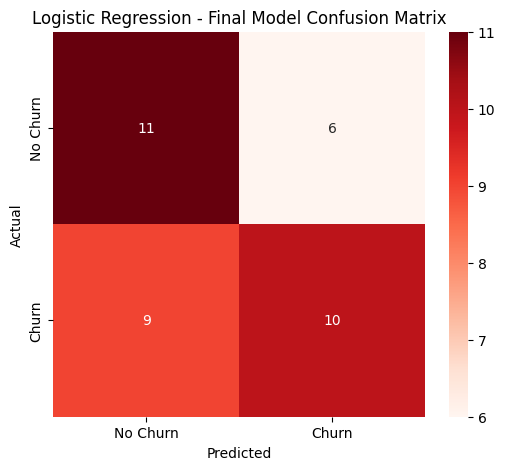

In [125]:
# Confusion Matrix
y_pred_final = logistic_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)
print("Confusion Matrix:")
print(cm)
plt.title('Logistic Regression - Final Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Confusion Matrix 

- **True Positive (TP) = 10:** 10 customers who actually churned were correctly predicted as churn.
- **True Negative (TN) = 11:** 11 customers who did not churn were correctly predicted as non-churn.
- **False Positive (FP) = 6:** 6 customers were predicted to churn but actually did not churn.
- **False Negative (FN) = 9:** 9 customers actually churned but were predicted as non-churn.

## Business Insights

1. **Month-to-month customers are more likely to churn.**
   The retention team should pay extra attention to these customers.

2. **Customers with low satisfaction are more likely to churn.**
   The company should contact unhappy customers and understand their problems.

3. **Newer customers show higher churn risk.**
   The company should provide better support during the early months.

4. **Customers with more support calls may have higher churn risk.**
   The company should check whether their problems have been properly solved.

5. **The churn model can help the retention team.**
   The team can use the model to identify customers who may leave and contact them early.



## Conclusion

The customer churn prediction problem was solved using different supervised learning models. After comparing their performance, Logistic Regression was selected as the final model because it showed more stable cross-validation performance.It achieved the highest CV F1-score of 64.36% and CV Recall of 68%. The model can help the retention team identify customers who are likely to churn and take early action to retain them.  



## Limitations

* The dataset is relatively small.
* Some factors that affect churn may not be included in the dataset.
* The model can make false positive and false negative predictions.
* More customer data and additional features could improve the model.